In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [25]:
df=pd.read_csv('titanic_imputation_practice_400_rows.csv')

In [26]:
df

,Age,Fare,Family,Survived
0,NaN,3.0210,0.0,1.0
1,28.1,8.1713,1.0,0.0
2,39.1,14.9580,0.0,0.0
3,51.3,15.5955,1.0,0.0
4,26.7,NaN,0.0,0.0
...,...,...,...,...
395,23.4,42.6554,NaN,1.0
396,6.0,NaN,1.0,0.0
397,NaN,29.4149,1.0,1.0
398,28.4,15.3071,0.0,0.0


In [27]:
df.head()

,Age,Fare,Family,Survived
0,NaN,3.0210,0.0,1.0
1,28.1,8.1713,1.0,0.0
2,39.1,14.9580,0.0,0.0
3,51.3,15.5955,1.0,0.0
4,26.7,NaN,0.0,0.0


In [28]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

using pandas

In [30]:
x_train['Age_99']=x_train['Age'].fillna(99)
x_train['Age_minus1']=x_train['Age'].fillna(-1)

x_train['Fare_888']=x_train['Fare'].fillna(888)
x_train['Fare_minus1']=x_train['Fare'].fillna(-1)

In [31]:
print('orignal value',x_train['Age'].var())
print('age after  arbitary_imputer',x_train['Age_99'].var())
print('age after  arbiatry minus1',x_train['Age_minus1'].var())
print('orignal value',x_train['Fare'].var())
print('fare after  arbitary_imputer',x_train['Fare_888'].var())
print('age after  arbitary minus1',x_train['Fare_minus1'].var())
# see now the value varience how huge amount of change is occur

orignal value 171.44376577973992
age after  arbitary_imputer 557.0703125979618
age after  arbiatry minus1 239.04327498040735
orignal value 821.2440027722591
fare after  arbitary_imputer 71810.0620267716
age after  arbitary minus1 794.232967096857


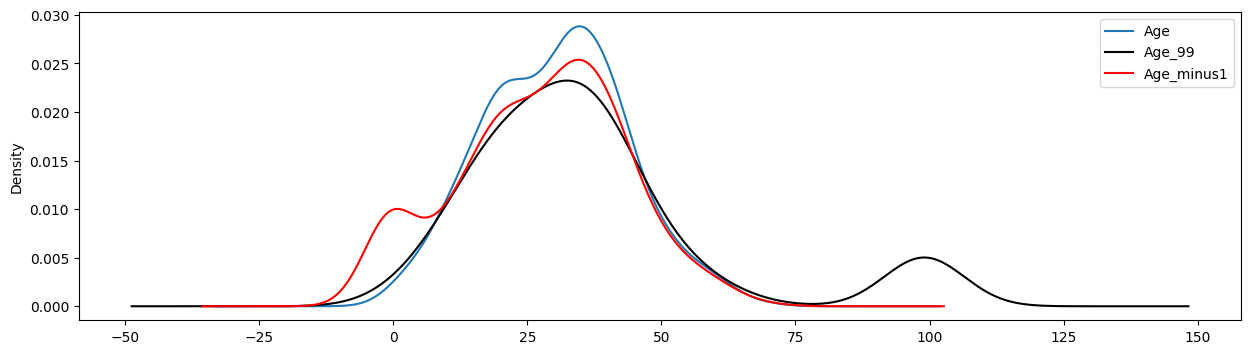

In [32]:
fig=plt.figure(figsize=(15,4))
ax=fig.add_subplot(111)

#orignal data
x_train['Age'].plot(kind='kde',ax=ax)
#99 age
x_train['Age_99'].plot(kind='kde',ax=ax,color='black')
#-1age
x_train['Age_minus1'].plot(kind='kde',ax=ax,color='red')
plt.legend()         

In [33]:
# same do for fare

In [34]:
x_train.cov()                    #covarience

,Age,Fare,Family,Age_99,Age_minus1,Fare_888,Fare_minus1
Age,171.443766,-37.501496,0.111881,171.443766,171.443766,188.384317,-39.995656
Fare,-37.501496,821.244003,0.357214,-75.456341,-15.061835,821.244003,821.244003
Family,0.111881,0.357214,0.249730,-0.596820,0.424060,-11.000388,0.637529
Age_99,171.443766,-75.456341,-0.596820,557.070313,-28.079570,-87.148900,-66.838106
Age_minus1,171.443766,-15.061835,0.424060,-28.079570,239.043275,288.362151,-22.263576
Fare_888,188.384317,821.244003,-11.000388,-87.148900,288.362151,71810.062027,-1340.296684
Fare_minus1,-39.995656,821.244003,0.637529,-66.838106,-22.263576,-1340.296684,794.232967


using sklearn

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
imputer1=SimpleImputer(strategy='constant',fill_value=99)
imputer2=SimpleImputer(strategy='constant',fill_value=777)

In [40]:
trf=ColumnTransformer([
('A_imputer1',imputer1,['Age']),
    ('A_imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [41]:
trf.fit(x_train)

,transformers,"[('A_imputer1', ...), ('A_imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [43]:
trf.named_transformers_['A_imputer1'].statistics_

array([99.])

In [44]:
trf.named_transformers_['A_imputer2'].statistics_

array([777.])

In [46]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [49]:
x_train

array([[5.130000e+01, 1.559550e+01, 1.000000e+00],
       [1.730000e+01, 4.839020e+01, 0.000000e+00],
       [4.520000e+01, 3.550260e+01, 1.000000e+00],
       [9.900000e+01, 9.453370e+01, 0.000000e+00],
       [1.630000e+01, 3.641800e+00, 0.000000e+00],
       [1.330000e+01, 1.843000e+01, 1.000000e+00],
       [5.470000e+01, 7.770000e+02, 0.000000e+00],
       [2.220000e+01, 4.247900e+01,          nan],
       [3.360000e+01, 1.561950e+01, 1.000000e+00],
       [9.900000e+01, 1.476160e+01, 0.000000e+00],
       [2.090000e+01, 9.709600e+00, 1.000000e+00],
       [2.790000e+01, 2.386940e+01, 1.000000e+00],
       [4.600000e+01, 1.643370e+01, 1.000000e+00],
       [6.240000e+01, 6.749900e+00, 1.000000e+00],
       [3.880000e+01, 2.087380e+01, 0.000000e+00],
       [4.830000e+01, 1.433010e+01, 1.000000e+00],
       [4.340000e+01, 3.935230e+01, 0.000000e+00],
       [1.820000e+01, 7.770000e+02, 1.000000e+00],
       [4.190000e+01, 7.770000e+02, 0.000000e+00],
       [4.150000e+01, 1.159950e